# Notebook 2 : Segmentation des Équipes par Clustering de Couleurs

## Objectif
Ce notebook se concentre sur la distinction automatique des deux équipes. L'objectif est d'analyser les pixels contenus dans les boîtes de détection des joueurs pour classer chaque individu dans l'équipe A ou l'équipe B (ou arbitre/gardien).


## 1. Fonction d'extraction de couleur
Pour différencier les équipes, nous devons analyser la couleur des maillots. Cette fonction prend une image, découpe la zone du joueur (bounding box), et extrait la couleur moyenne du centre du maillot (pour éviter le vert de la pelouse en arrière-plan).

In [1]:
import cv2
import numpy as np

def get_player_color(image, bbox):
    #  Coordonnées de la boîte
    x1, y1, x2, y2 = map(int, bbox)
    w = x2 - x1
    h = y2 - y1
    
    # Cadrage strict sur le maillot (Torse)
    # On garde de 15% à 50% de la hauteur (évite tête et jambes)
    # On garde le centre en largeur (évite l'arrière-plan)
    crop = image[y1 + int(h * 0.15):y1 + int(h * 0.50), 
                 x1 + int(w * 0.25):x1 + int(w * 0.75)]
    
    if crop.size == 0: return None

    #  Supprimer le vert de la pelouse
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    # Définition du vert (Teinte 35 à 85)
    mask_green = cv2.inRange(hsv, np.array([35, 30, 30]), np.array([85, 255, 255]))
    
    # On garde uniquement les pixels NON verts
    pixels_maillot = crop[mask_green == 0]
    
    if len(pixels_maillot) < 5: return None 
    
    # Retourner la couleur médiane (plus fiable que la moyenne)
    return np.median(pixels_maillot, axis=0)

## 2. Collecte des données
Nous allons repasser sur quelques frames de la vidéo pour collecter une liste de couleurs de joueurs. Cela servira de base d'entraînement pour notre algorithme K-Means.

In [2]:
from ultralytics import YOLO
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

model = YOLO('yolov8m.pt')
cap = cv2.VideoCapture("input_video.mp4")

player_colors = []

# Récupérer le nombre total de frames
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

start_frame = 0

# On va piocher 50 images aléatoirement dans la vidéo 
for _ in range(60):
    random_frame = random.randint(start_frame, total_frames - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame)
    ret, frame = cap.read()
    if not ret: continue
    results = model(frame, classes=[0], verbose=False) # Classe 0 = Personne
    for box in results[0].boxes.xyxy.cpu().numpy():
        color = get_player_color(frame, box)
        if color is not None:
            player_colors.append(color)

cap.release()
print(f"Nb d'échantillons de couleurs collectés : {len(player_colors)}")

Nb d'échantillons de couleurs collectés : 1253


## 3. Entraînement du K-Means
Nous demandons à l'algorithme de trouver 2 groupes principaux (Cluster 0 et Cluster 1) parmi toutes les couleurs collectées.

In [3]:
# Conversion en array numpy
data = np.array(player_colors)

# K-Means avec 2 clusters (Equipe A et Equipe B)
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans.fit(data)

print("Centres des clusters (Couleurs principales détectées en BGR) :")
print(kmeans.cluster_centers_)

Centres des clusters (Couleurs principales détectées en BGR) :
[[      85.75      65.289      46.424]
 [     100.32      121.16      155.91]]


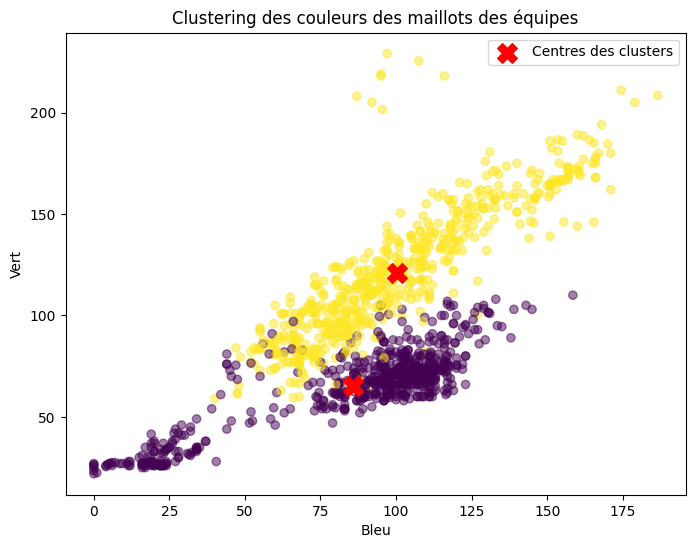

In [4]:
# Visualisation des clusters
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap='viridis', marker='o', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centres des clusters')
plt.xlabel('Bleu')
plt.ylabel('Vert')
plt.title('Clustering des couleurs des maillots des équipes')
plt.legend()
plt.show()

## 4. Visualisation des équipes
Affichons les deux couleurs dominantes trouvées pour vérifier qu'elles correspondent bien aux maillots des deux équipes.

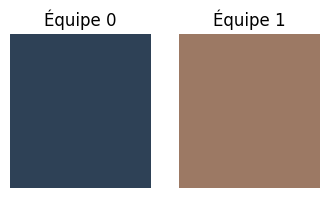

In [5]:
def plot_colors(centers):
    fig, ax = plt.subplots(1, 2, figsize=(4, 2))
    for i, center in enumerate(centers):
        # Convertir BGR vers RGB pour matplotlib
        color_rgb = center[::-1] / 255.0 
        ax[i].set_title(f"Équipe {i}")
        ax[i].add_patch(plt.Rectangle((0, 0), 1, 1, color=color_rgb))
        ax[i].axis('off')
    plt.show()

plot_colors(kmeans.cluster_centers_)

# Sauvegarde du modèle (optionnel, on peut aussi juste garder kmeans en mémoire)
import pickle
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Obs
Équipe 1 (Teinte Marron/Ocre) : Cette couleur représente la valeur médiane des maillots de la première équipe. Bien que l'équipe 0 porte du rouge  dans la réalité, la couleur apparaît ici plus terne. Cela s'explique par la moyenne mathématique effectuée sur les pixels du maillot qui inclut les zones d'ombres (plis du tissu) et les variations de lumière sur le terrain.

Équipe 0 (Teinte Bleu Nuit/Gris) : Cette couleur correspond à la seconde équipe. C'est une teinte sombre et saturée, bien distincte de la première.

Conclusion sur le clustering : Bien que les couleurs ne soient pas "vives", elles sont mathématiquement très éloignées dans l'espace colorimétrique. Cela suffit amplement à l'ordinateur pour classifier chaque joueur avec précision (Rouge vs Bleu).
